✅ Data breach fixed: Only using training set statistics
CV Scores: [0.77055779 0.7786084  0.80563542 0.83084005 0.80207135]
Mean Accuracy: 0.7975426005051646
交叉验证准确率: 0.7975 (+/- 0.0214)


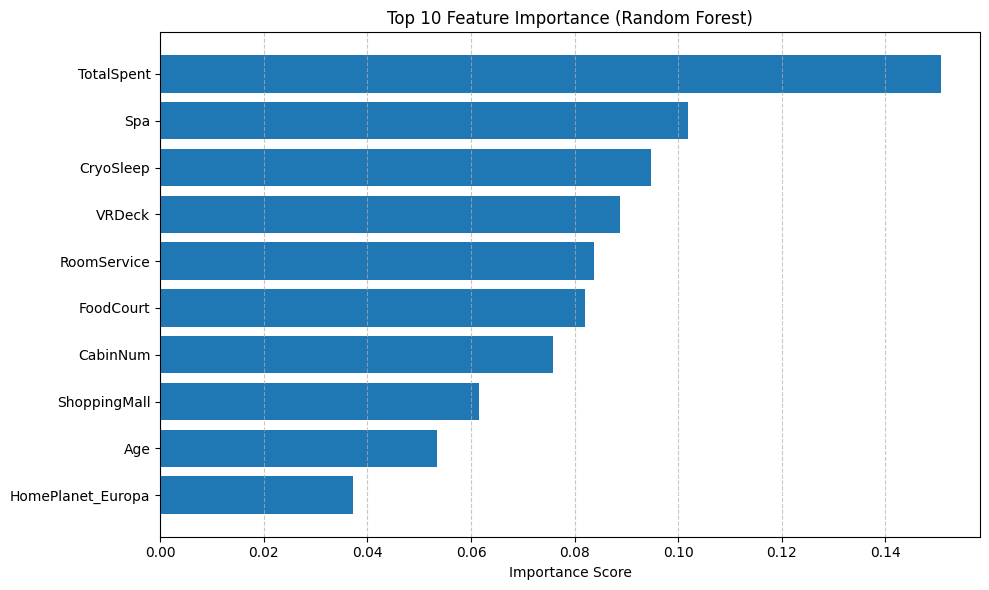

Top 10 Feature Importances:
 1. HomePlanet_Europa    : 0.0371
 2. Age                  : 0.0534
 3. ShoppingMall         : 0.0616
 4. CabinNum             : 0.0758
 5. FoodCourt            : 0.0820
 6. RoomService          : 0.0837
 7. VRDeck               : 0.0887
 8. CryoSleep            : 0.0948
 9. Spa                  : 0.1018
10. TotalSpent           : 0.1507


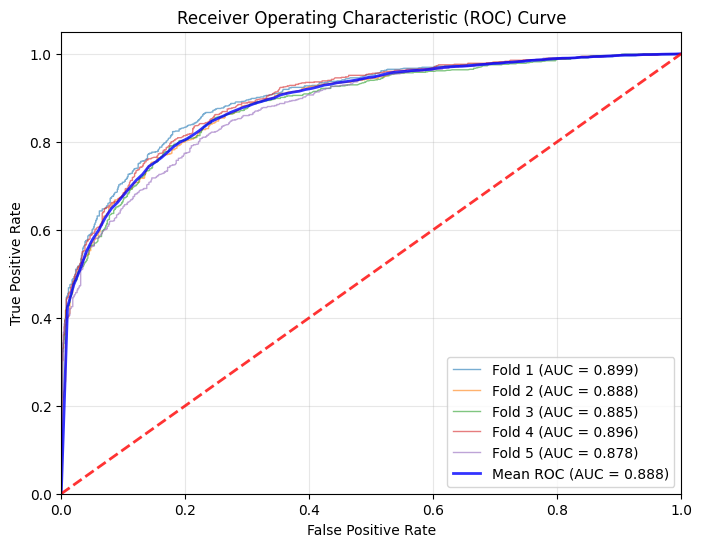

✅ Average AUC score: 0.8878
✅ submission.csv generated


In [4]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')


# ==========================================================
# Step 1: Load Data
# ==========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

test_ids = test["PassengerId"]
y = train["Transported"].astype(int)

# Combine train + test
full = pd.concat(
    [train.drop("Transported", axis=1), test],
    axis=0
).reset_index(drop=True)

# ==========================================================
# Step 2: Feature Engineering
# ==========================================================

# Group Features
full["GroupID"] = full["PassengerId"].str.split("_").str[0]
full["GroupSize"] = full.groupby("GroupID")["GroupID"].transform("count")

# Cabin Features
full[["Deck", "CabinNum", "Side"]] = full["Cabin"].str.split("/", expand=True)
full["CabinNum"] = pd.to_numeric(full["CabinNum"], errors="coerce")

# Spending Features
spend_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

for col in spend_cols:
    full[col] = full[col].fillna(0)

full["TotalSpent"] = full[spend_cols].sum(axis=1)

# Age
full["Age"] = full["Age"].fillna(full["Age"].median())

# Boolean Features
full["CryoSleep"] = full["CryoSleep"].fillna(False).astype(int)
full["VIP"] = full["VIP"].fillna(False).astype(int)

# ==========================================================
# Step 3: Fill Missing Values
# ==========================================================
for col in full.columns:

    if full[col].dtype == "object":
        full[col] = full[col].fillna(full[col].mode()[0])

    else:
        full[col] = full[col].fillna(full[col].median())
# ================================
# Step 3.5: Split the training set and test set (fixing leakage issues)
# ================================

# First, split the full dataset back into train and test sets logically.
train_processed = full.iloc[:len(train)].copy()
test_processed = full.iloc[len(train):].copy()

# Define numerical and categorical columns
num_cols = train_processed.select_dtypes(include=[np.number]).columns
cat_cols = train_processed.select_dtypes(exclude=[np.number]).columns

# 1. Calculate the median/mode only on the training set
num_medians = train_processed[num_cols].median()
cat_modes = {}

# 2. Fill the training set and test set with the statistical values from the training set
for col in cat_cols:
    cat_modes[col] = train_processed[col].mode()[0]

# Fill in the value
train_processed[num_cols] = train_processed[num_cols].fillna(num_medians)
test_processed[num_cols] = test_processed[num_cols].fillna(num_medians)

# Filling category
for col in cat_cols:
    train_processed[col] = train_processed[col].fillna(cat_modes[col])
    test_processed[col] = test_processed[col].fillna(cat_modes[col])

print("✅ Data breach fixed: Only using training set statistics")


# ==========================================================
# Step 4: Drop Weak Columns
# ==========================================================
full.drop(
    ["PassengerId", "Cabin", "Name", "GroupID"],
    axis=1,
    inplace=True
)

# ==========================================================
# Step 5: One-Hot Encoding
# ==========================================================
full = pd.get_dummies(
    full,
    columns=["HomePlanet", "Destination", "Deck", "Side"],
    drop_first=True
)

# ==========================================================
# Step 6: Split Train / Test
# ==========================================================
X = full.iloc[:len(train), :]
X_test = full.iloc[len(train):, :]

# ==========================================================
# Step 7: Breakthrough Random Forest
# ==========================================================
rf = RandomForestClassifier(
    n_estimators=2600,
    max_depth=12,
    min_samples_leaf=2,
    min_samples_split=12,
    max_features="log2",
    criterion="entropy",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# ==========================================================
# Step 8: Print Accuracy
# ==========================================================
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print(f"交叉验证准确率: {scores.mean():.4f} (+/- {scores.std():.4f})")


# ================================
# Step 9: Train Full Model
# ================================
rf.fit(X, y)

# ================================
# Step 9.5: Feature Importance Analysis
# ================================
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance
importances = rf.feature_importances_
features = X.columns

# Sort and take the top 10 most important features
indices = np.argsort(importances)[-10:]  # 取最后10个（最大的）
top_features = features[indices]
top_importances = importances[indices]

# Drawing
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importance (Random Forest)")
plt.barh(range(len(indices)), top_importances, align="center")
plt.yticks(range(len(indices)), top_features)
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print importance value 
print("Top 10 Feature Importances:")
for i, (feat, imp) in enumerate(zip(top_features, top_importances)):
    print(f"{i+1:2d}. {feat:20s} : {imp:.4f}")

from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Obtain probabilities using cross-validation 
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(8, 6))

for i, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    rf_cv = RandomForestClassifier(
        n_estimators=2000,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    rf_cv.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # Predicted probability
    probas = rf_cv.predict_proba(X.iloc[val_idx])[:, 1]
    
    # Calculate ROC
    fpr, tpr, _ = roc_curve(y.iloc[val_idx], probas)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, lw=1, alpha=0.6, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(roc_auc)

# Plot the average ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

ax.plot(mean_fpr, mean_tpr, color='b',
        label=f'Mean ROC (AUC = {mean_auc:.3f})', lw=2, alpha=0.8)
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=0.8)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"✅ Average AUC score: {mean_auc:.4f}")


# ================================
# Step 10: Predict Test Set
# ================================
pred = rf.predict(X_test)

# ================================
# Step 11: Create Submission
# ================================
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": pred.astype(bool)
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv generated")
